# Visualization Module

Produces **5 charts** (4 required + 1 bonus) from cleaned price data.

| # | Chart | Type |
|---|-------|------|
| 1 | Price trend + volume overlay | Interactive line + bar (Plotly) |
| 2 | Correlation heatmap of daily returns | Seaborn heatmap |
| 3 | Distribution of daily returns | Violin / KDE (Plotly) |
| 4 | Bollinger Bands (rolling statistics) | Interactive line + fill (Plotly) |
| 5 | Normalised performance comparison | Multi-line indexed (Plotly) |

HTML charts are saved to `outputs/charts/`. Static charts saved as PNG.

In [11]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings("ignore")
os.makedirs("outputs/charts", exist_ok=True)

# Open Plotly charts in the browser (avoids nbformat dependency)
pio.renderers.default = "browser"

# ── Tickers to visualise ────────────────────────────────────────────────────
FOCUS_TICKERS = ["AAPL", "MSFT", "GOOGL", "AMZN", "META", "NVDA", "JPM", "JNJ"]
CHART_TICKER  = "AAPL"   # single-ticker charts (Chart 1 & 4)
BB_TICKER     = "NVDA"   # Bollinger Bands ticker
START_2Y      = "2024-01-01"   # window for 2-year views

print("Visualization Module")
print("=" * 50)
print(f"Focus tickers : {FOCUS_TICKERS}")
print(f"Price trend   : {CHART_TICKER}")
print(f"Bollinger     : {BB_TICKER}")
print(f"Plotly renderer: {pio.renderers.default}")

Visualization Module
Focus tickers : ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'NVDA', 'JPM', 'JNJ']
Price trend   : AAPL
Bollinger     : NVDA
Plotly renderer: browser


In [12]:
# ── Load cleaned price data ─────────────────────────────────────────────────
price_df = pd.read_csv("data/cleaned/prices_clean.csv", parse_dates=["Date"])
price_df = price_df[price_df["Ticker"].isin(FOCUS_TICKERS)].copy()
price_df = price_df.sort_values(["Ticker", "Date"])

price_2y = price_df[price_df["Date"] >= START_2Y].copy()

print(f"Loaded  : {price_df.shape[0]:,} rows | {price_df['Ticker'].nunique()} tickers")
print(f"Range   : {price_df['Date'].min().date()} → {price_df['Date'].max().date()}")
print(f"2-year  : {price_2y['Date'].min().date()} → {price_2y['Date'].max().date()}")

Loaded  : 22,952 rows | 8 tickers
Range   : 2015-01-02 → 2025-12-31
2-year  : 2024-01-01 → 2025-12-31


## Chart 1 — Price Trend with Volume Overlay

In [13]:
df1 = price_2y[price_2y["Ticker"] == CHART_TICKER].copy()

fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.04,
    row_heights=[0.75, 0.25],
    subplot_titles=(f"{CHART_TICKER} — Close Price & Moving Averages", "Volume"),
)

fig.add_trace(go.Scatter(
    x=df1["Date"], y=df1["Close"],
    name="Close", line=dict(color="#1f77b4", width=2)
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=df1["Date"], y=df1["ma7"],
    name="7-day MA", line=dict(color="#ff7f0e", width=1.2, dash="dot")
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=df1["Date"], y=df1["ma30"],
    name="30-day MA", line=dict(color="#2ca02c", width=1.8)
), row=1, col=1)

fig.add_trace(go.Bar(
    x=df1["Date"], y=df1["Volume"],
    name="Volume", marker_color="rgba(100,100,200,0.4)"
), row=2, col=1)

fig.update_layout(
    title=f"{CHART_TICKER} — Price Trend with Volume Overlay (2024–2025)",
    height=600, template="plotly_white",
    legend=dict(orientation="h", yanchor="bottom", y=1.02),
    yaxis_title="Price (USD)",
    yaxis2_title="Volume",
    xaxis2_title="Date",
)

out = "outputs/charts/chart1_price_trend.html"
fig.write_html(out)
fig.show()
print(f"Saved: {out}")

Saved: outputs/charts/chart1_price_trend.html


## Chart 2 — Correlation Heatmap of Daily Returns

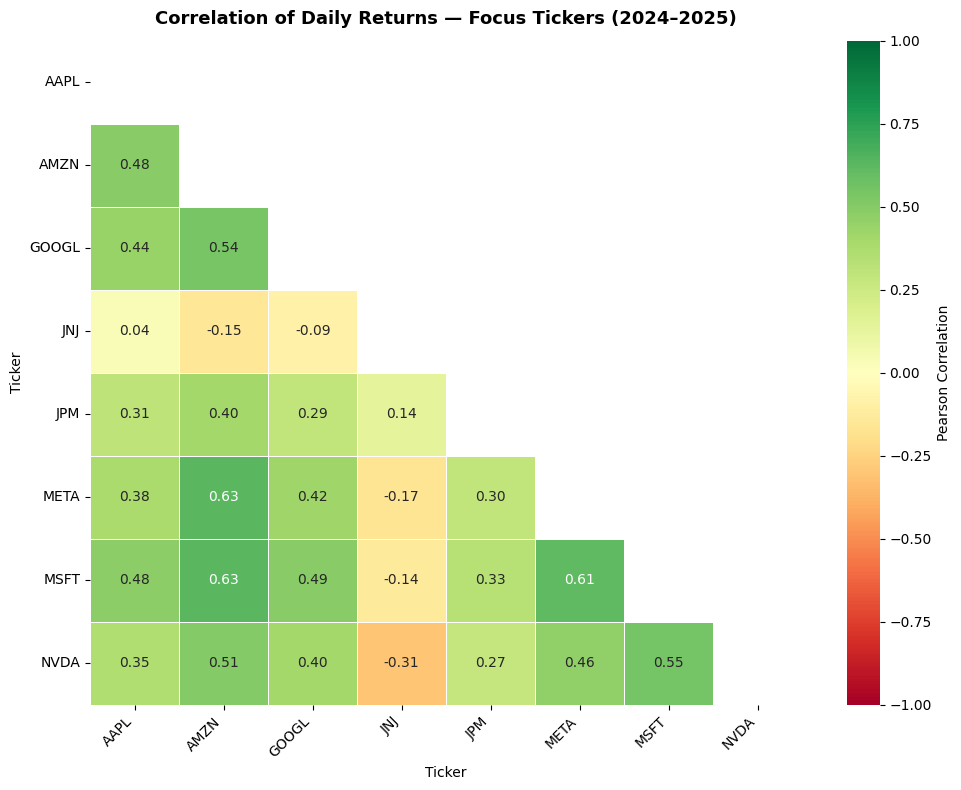

Saved: outputs/charts/chart2_correlation_heatmap.png


In [14]:
returns_wide = (
    price_2y
    .pivot_table(index="Date", columns="Ticker", values="daily_return")
    .dropna(how="all")
)
corr = returns_wide.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))   # hide upper triangle

fig2, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr, mask=mask,
    annot=True, fmt=".2f",
    cmap="RdYlGn", vmin=-1, vmax=1,
    linewidths=0.5, ax=ax,
    cbar_kws={"label": "Pearson Correlation"},
)
ax.set_title("Correlation of Daily Returns — Focus Tickers (2024–2025)",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()

out = "outputs/charts/chart2_correlation_heatmap.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out}")

## Chart 3 — Distribution of Daily Returns (Violin Plot)

In [15]:
fig3 = go.Figure()
for ticker in FOCUS_TICKERS:
    ret = price_df[price_df["Ticker"] == ticker]["daily_return"].dropna()
    fig3.add_trace(go.Violin(
        x=[ticker] * len(ret), y=ret,
        name=ticker,
        box_visible=True,
        meanline_visible=True,
        points="outliers",
    ))

fig3.update_layout(
    title="Distribution of Daily Returns — Focus Tickers (Full History)",
    xaxis_title="Ticker",
    yaxis_title="Daily Return",
    yaxis=dict(tickformat=".1%"),
    template="plotly_white",
    height=550,
    showlegend=False,
)

out = "outputs/charts/chart3_return_distribution.html"
fig3.write_html(out)
fig3.show()
print(f"Saved: {out}")

Saved: outputs/charts/chart3_return_distribution.html


## Chart 4 — Bollinger Bands (Rolling Statistics)

In [16]:
df4 = price_2y[price_2y["Ticker"] == BB_TICKER].dropna(subset=["bb_upper", "bb_lower"]).copy()

fig4 = go.Figure()

# Shaded band fill
fig4.add_trace(go.Scatter(
    x=df4["Date"], y=df4["bb_upper"],
    name="Upper Band (2σ)",
    line=dict(color="rgba(173,173,220,0.5)", width=1),
    mode="lines",
))
fig4.add_trace(go.Scatter(
    x=df4["Date"], y=df4["bb_lower"],
    name="Lower Band (2σ)",
    line=dict(color="rgba(173,173,220,0.5)", width=1),
    fill="tonexty", fillcolor="rgba(173,173,220,0.2)",
    mode="lines",
))
# Midline (20-day MA)
fig4.add_trace(go.Scatter(
    x=df4["Date"], y=df4["bb_mid"],
    name="20-day MA",
    line=dict(color="#ff7f0e", width=1.5, dash="dot"),
))
# Close price
fig4.add_trace(go.Scatter(
    x=df4["Date"], y=df4["Close"],
    name="Close",
    line=dict(color="#1f77b4", width=2),
))

fig4.update_layout(
    title=f"{BB_TICKER} — Bollinger Bands (20-day, ±2σ) 2024–2025",
    xaxis_title="Date",
    yaxis_title="Price (USD)",
    template="plotly_white",
    height=550,
    legend=dict(orientation="h", yanchor="bottom", y=1.02),
)

out = "outputs/charts/chart4_bollinger_bands.html"
fig4.write_html(out)
fig4.show()
print(f"Saved: {out}")

Saved: outputs/charts/chart4_bollinger_bands.html


## Chart 5 — Normalised Performance Comparison

In [17]:
df5 = price_2y.sort_values(["Ticker", "Date"]).copy()

# Explicit loop — pandas 3.x groupby.apply drops the groupby-key column
norm_chunks = []
for ticker, group in df5.groupby("Ticker"):
    first = group["Close"].iloc[0]
    group = group.copy()
    group["norm_price"] = group["Close"] / first * 100 if first else np.nan
    group["Ticker"] = ticker
    norm_chunks.append(group)
df5 = pd.concat(norm_chunks).reset_index(drop=True)

fig5 = px.line(
    df5, x="Date", y="norm_price", color="Ticker",
    title=f"Normalised Price Performance (Base = 100, from {START_2Y})",
    labels={"norm_price": "Indexed Price (Base 100)", "Date": "Date"},
    template="plotly_white",
    height=550,
)
fig5.add_hline(y=100, line_dash="dash", line_color="gray",
               annotation_text="Base (100)", annotation_position="bottom right")

out = "outputs/charts/chart5_normalised_performance.html"
fig5.write_html(out)
fig5.show()
print(f"Saved: {out}")

Saved: outputs/charts/chart5_normalised_performance.html


## Summary of saved outputs

In [18]:
charts_dir = "outputs/charts"
files = sorted(os.listdir(charts_dir))
print(f"Charts saved to {charts_dir}/")
for f in files:
    size_kb = os.path.getsize(f"{charts_dir}/{f}") // 1024
    print(f"  {f:<45}  {size_kb:>5} KB")

Charts saved to outputs/charts/
  chart1_price_trend.html                         4823 KB
  chart2_correlation_heatmap.png                    89 KB
  chart3_return_distribution.html                 5193 KB
  chart4_bollinger_bands.html                     4823 KB
  chart5_normalised_performance.html              4907 KB


## Dashboard — Combined Interactive Web Page

In [19]:

import base64, pathlib, datetime
import plotly.graph_objects as go

# ── Helper: copy fig, apply dark theme, return embedded HTML div ─────────────
def _div(fig_obj, h=None):
    f = go.Figure(fig_obj)
    if h:
        f.update_layout(height=h)
    f.update_layout(
        paper_bgcolor="rgba(0,0,0,0)",
        plot_bgcolor="#10161e",
        font=dict(color="#c9d1d9"),
        title_font_color="#e6edf3",
        legend=dict(bgcolor="rgba(22,27,34,0.85)", bordercolor="#30363d", borderwidth=1),
    )
    f.update_xaxes(gridcolor="#1c2128", linecolor="#30363d",
                   tickfont_color="#8b949e", title_font_color="#8b949e")
    f.update_yaxes(gridcolor="#1c2128", linecolor="#30363d",
                   tickfont_color="#8b949e", title_font_color="#8b949e")
    return f.to_html(
        full_html=False,
        include_plotlyjs=False,
        config={
            "responsive": True,
            "displaylogo": False,
            "modeBarButtonsToRemove": ["lasso2d", "select2d"],
            "toImageButtonOptions": {"format": "png", "filename": "chart", "scale": 2},
        },
    )

# ── Helper: PNG → base-64 data-URI ───────────────────────────────────────────
def _b64(path):
    return "data:image/png;base64," + base64.b64encode(
        pathlib.Path(path).read_bytes()
    ).decode()

# ── Build chart divs (compact for overview, full for individual tabs) ─────────
c1_full = _div(fig)
c1_mini = _div(fig, 380)
c3_full = _div(fig3)
c3_mini = _div(fig3, 380)
c4_full = _div(fig4)
c4_mini = _div(fig4, 380)
c5_full = _div(fig5)
c5_mini = _div(fig5, 380)
heatmap_src = _b64("outputs/charts/chart2_correlation_heatmap.png")

# ── Summary stats for KPI cards ───────────────────────────────────────────────
date_range   = (f"{price_2y['Date'].min():%b %d, %Y}"
                f" – {price_2y['Date'].max():%b %d, %Y}")
generated_ts = f"{datetime.datetime.now():%B %d, %Y  %H:%M}"
n_tick       = len(FOCUS_TICKERS)
n_pairs      = n_tick * (n_tick - 1) // 2
tickers_chips = "".join(
    f'<span class="ticker-chip">{t}</span>' for t in FOCUS_TICKERS
)

latest_ret = (
    price_2y.sort_values("Date")
    .groupby("Ticker").last()["daily_return"].dropna()
)
best_t,  best_v  = latest_ret.idxmax(), f"{latest_ret.max()*100:+.2f}%"
worst_t, worst_v = latest_ret.idxmin(), f"{latest_ret.min()*100:+.2f}%"
avg_vol = (
    f"{price_2y.groupby('Ticker')['vol_30d'].last().mean()*100:.1f}%"
    if "vol_30d" in price_2y.columns else "N/A"
)

# ── CSS (plain string — CSS braces are not Python, safe here) ─────────────────
CSS = """
*,*::before,*::after{box-sizing:border-box;margin:0;padding:0}
:root{
  --bg:#0d1117;--s1:#161b22;--s2:#21262d;--s3:#2d333b;
  --bd:#30363d;--bd2:#444c56;
  --ac:#58a6ff;--gn:#3fb950;--rd:#f85149;--am:#e3b341;
  --tx:#e6edf3;--mt:#8b949e;--sb:#6e7681;
  --r:12px;
}
body{font-family:'Inter',system-ui,-apple-system,sans-serif;
  background:var(--bg);color:var(--tx);min-height:100vh}
::-webkit-scrollbar{width:6px;height:6px}
::-webkit-scrollbar-track{background:var(--s1)}
::-webkit-scrollbar-thumb{background:var(--bd2);border-radius:3px}

/* HEADER */
.hdr{position:sticky;top:0;z-index:200;
  background:rgba(13,17,23,.9);backdrop-filter:blur(16px);
  border-bottom:1px solid var(--bd);padding:0 2rem}
.hdr-in{max-width:1440px;margin:0 auto;
  display:flex;align-items:center;justify-content:space-between;height:62px}
.brand{display:flex;align-items:center;gap:11px}
.brand-icon{width:38px;height:38px;
  background:linear-gradient(135deg,#58a6ff,#1f6feb);
  border-radius:9px;display:flex;align-items:center;justify-content:center;
  font-size:20px;flex-shrink:0;box-shadow:0 2px 12px rgba(88,166,255,.4)}
.brand-name{font-size:1.05rem;font-weight:700;letter-spacing:-.02em}
.brand-sub{font-size:.68rem;color:var(--mt);margin-top:1px}
.hdr-r{display:flex;align-items:center;gap:8px}
.pill{display:inline-flex;align-items:center;gap:5px;
  padding:4px 10px;border-radius:20px;font-size:.68rem;font-weight:600;letter-spacing:.04em}
.pill-bl{background:rgba(88,166,255,.14);color:var(--ac);border:1px solid rgba(88,166,255,.28)}
.pill-gn{background:rgba(63,185,80,.14);color:var(--gn);border:1px solid rgba(63,185,80,.28)}

/* HERO */
.hero{background:linear-gradient(160deg,#161b22 0%,#0d1117 65%);
  border-bottom:1px solid var(--bd);padding:3.5rem 2rem 2.5rem}
.hero-in{max-width:1440px;margin:0 auto}
.hero h2{font-size:2.5rem;font-weight:800;letter-spacing:-.045em;
  background:linear-gradient(135deg,#e6edf3 0%,#58a6ff 100%);
  -webkit-background-clip:text;-webkit-text-fill-color:transparent;
  background-clip:text;margin-bottom:.55rem}
.hero p{color:var(--mt);font-size:.93rem;line-height:1.65;max-width:640px}
.tickers-row{display:flex;flex-wrap:wrap;gap:6px;margin-top:1.3rem}
.ticker-chip{padding:5px 12px;border-radius:7px;
  background:var(--s2);border:1px solid var(--bd);
  font-size:.73rem;font-weight:600;color:var(--mt);letter-spacing:.05em;
  transition:all .15s;cursor:default}
.ticker-chip:hover{color:var(--ac);border-color:var(--ac);background:rgba(88,166,255,.08)}

/* KPI STRIP */
.kpi-strip{max-width:1440px;margin:2rem auto 0;padding:0 2rem;
  display:grid;grid-template-columns:repeat(auto-fit,minmax(180px,1fr));gap:.9rem}
.kpi{background:var(--s1);border:1px solid var(--bd);border-radius:var(--r);
  padding:1.2rem 1.4rem;transition:transform .15s,border-color .15s}
.kpi:hover{transform:translateY(-2px);border-color:var(--bd2)}
.kpi-lbl{font-size:.66rem;font-weight:600;color:var(--sb);
  text-transform:uppercase;letter-spacing:.1em;margin-bottom:.4rem}
.kpi-val{font-size:1.5rem;font-weight:700;letter-spacing:-.03em}
.kpi-val.sm{font-size:.95rem;margin-top:3px}
.kpi-note{font-size:.73rem;color:var(--mt);margin-top:3px}
.bl{color:var(--ac)}.gn{color:var(--gn)}.rd{color:var(--rd)}.am{color:var(--am)}

/* MAIN */
.main{max-width:1440px;margin:0 auto;padding:2rem 2rem 5rem}

/* TABS */
.tab-bar{display:flex;gap:3px;background:var(--s1);border:1px solid var(--bd);
  border-radius:10px;padding:4px;margin-bottom:1.75rem;
  overflow-x:auto;scrollbar-width:none}
.tab-bar::-webkit-scrollbar{display:none}
.tab-btn{flex:1;min-width:130px;padding:9px 14px;
  background:transparent;border:none;border-radius:7px;
  color:var(--mt);font-size:.78rem;font-weight:600;
  cursor:pointer;transition:all .18s;font-family:inherit;
  white-space:nowrap;text-align:center}
.tab-btn:hover{color:var(--tx);background:var(--s2)}
.tab-btn.active{background:var(--ac);color:#fff;box-shadow:0 2px 10px rgba(88,166,255,.35)}

/* PANELS */
.panel{display:none}
.panel.active{display:block;animation:fd .22s ease}
@keyframes fd{from{opacity:0;transform:translateY(7px)}to{opacity:1;transform:translateY(0)}}

/* OVERVIEW GRID */
.ov-grid{display:grid;grid-template-columns:1fr 1fr;gap:1.2rem}
.ov-span{grid-column:1/-1}

/* CHART CARD */
.card{background:var(--s1);border:1px solid var(--bd);border-radius:var(--r);overflow:hidden}
.card-head{padding:1.2rem 1.5rem 1rem;border-bottom:1px solid var(--bd);
  display:flex;align-items:flex-start;justify-content:space-between;gap:1rem}
.card-head-l h3{font-size:1rem;font-weight:700;letter-spacing:-.02em;margin-bottom:3px}
.card-head-l p{font-size:.77rem;color:var(--mt);line-height:1.5;max-width:560px}
.tags{display:flex;gap:5px;flex-shrink:0;flex-wrap:wrap;margin-top:1px}
.tag{padding:3px 8px;border-radius:5px;font-size:.66rem;font-weight:700;letter-spacing:.04em}
.t-i{background:rgba(88,166,255,.13);color:var(--ac)}
.t-s{background:rgba(227,179,65,.13);color:var(--am)}
.t-t{background:rgba(63,185,80,.13);color:var(--gn)}
.t-r{background:rgba(248,81,73,.13);color:var(--rd)}
.card-body{padding:.75rem;background:#0a0e14}
.card-body img{width:100%;border-radius:8px;display:block}

/* SINGLE CHART VIEW */
.single{display:grid;gap:1.25rem}
.ic-row{display:grid;grid-template-columns:repeat(auto-fit,minmax(175px,1fr));gap:.85rem}
.ic{background:var(--s1);border:1px solid var(--bd);border-radius:9px;padding:1rem 1.2rem}
.ic-lbl{font-size:.66rem;font-weight:600;color:var(--sb);
  text-transform:uppercase;letter-spacing:.1em;margin-bottom:.35rem}
.ic-val{font-size:1.05rem;font-weight:700}

/* FOOTER */
.footer{border-top:1px solid var(--bd);padding:1.5rem 2rem;
  text-align:center;color:var(--sb);font-size:.73rem}

/* RESPONSIVE */
@media(max-width:900px){
  .ov-grid{grid-template-columns:1fr}
  .ov-span{grid-column:auto}
  .hero h2{font-size:1.85rem}
  .kpi-strip,.main{padding-left:1rem;padding-right:1rem}
  .hdr{padding:0 1rem}
  .hero{padding:2.5rem 1rem 2rem}
}
"""

# ── JS (plain string) ─────────────────────────────────────────────────────────
JS = """
function showTab(name) {
  document.querySelectorAll('.panel').forEach(p => p.classList.remove('active'));
  document.querySelectorAll('.tab-btn').forEach(b => b.classList.remove('active'));
  document.getElementById('panel-' + name).classList.add('active');
  document.querySelector('[data-tab="' + name + '"]').classList.add('active');
}
"""

# ── Assemble final HTML ────────────────────────────────────────────────────────
html = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8"/>
<meta name="viewport" content="width=device-width,initial-scale=1.0"/>
<title>FinTech Dashboard — S&P 500 Market Analysis</title>
<script src="https://cdn.plot.ly/plotly-2.32.0.min.js"></script>
<link href="https://fonts.googleapis.com/css2?family=Inter:wght@300;400;500;600;700;800&display=swap" rel="stylesheet"/>
<style>{CSS}</style>
</head>
<body>

<!-- ── HEADER ── -->
<header class="hdr">
  <div class="hdr-in">
    <div class="brand">
      <div class="brand-icon">📈</div>
      <div>
        <div class="brand-name">FinTech Dashboard</div>
        <div class="brand-sub">S&amp;P 500 · Market Intelligence</div>
      </div>
    </div>
    <div class="hdr-r">
      <span class="pill pill-gn">&#9679; Live Data</span>
      <span class="pill pill-bl">Groq · Llama 3.3 70B</span>
    </div>
  </div>
</header>

<!-- ── HERO ── -->
<section class="hero">
  <div class="hero-in">
    <h2>Market Visualisation</h2>
    <p>Interactive charts and analytics for <strong>{n_tick}</strong> S&amp;P 500 equities.
       Covering price trends, volatility, return distributions, Bollinger Bands
       and normalised performance comparisons.</p>
    <div class="tickers-row">{tickers_chips}</div>
  </div>
</section>

<!-- ── KPI STRIP ── -->
<div class="kpi-strip">
  <div class="kpi">
    <div class="kpi-lbl">Tickers Tracked</div>
    <div class="kpi-val bl">{n_tick}</div>
    <div class="kpi-note">S&amp;P 500 equities</div>
  </div>
  <div class="kpi">
    <div class="kpi-lbl">Analysis Window</div>
    <div class="kpi-val sm">{date_range}</div>
    <div class="kpi-note">2-year price history</div>
  </div>
  <div class="kpi">
    <div class="kpi-lbl">Best Last Day</div>
    <div class="kpi-val gn">{best_t}</div>
    <div class="kpi-note">{best_v} daily return</div>
  </div>
  <div class="kpi">
    <div class="kpi-lbl">Worst Last Day</div>
    <div class="kpi-val rd">{worst_t}</div>
    <div class="kpi-note">{worst_v} daily return</div>
  </div>
  <div class="kpi">
    <div class="kpi-lbl">Avg 30-Day Vol</div>
    <div class="kpi-val am">{avg_vol}</div>
    <div class="kpi-note">annualised, all tickers</div>
  </div>
</div>

<!-- ── MAIN ── -->
<main class="main">

  <!-- NAV TABS -->
  <div class="tab-bar">
    <button class="tab-btn active" data-tab="overview" onclick="showTab('overview')">&#8862;&nbsp; Overview</button>
    <button class="tab-btn" data-tab="c1" onclick="showTab('c1')">Chart 1 · Price Trend</button>
    <button class="tab-btn" data-tab="c2" onclick="showTab('c2')">Chart 2 · Correlation</button>
    <button class="tab-btn" data-tab="c3" onclick="showTab('c3')">Chart 3 · Returns</button>
    <button class="tab-btn" data-tab="c4" onclick="showTab('c4')">Chart 4 · Bollinger</button>
    <button class="tab-btn" data-tab="c5" onclick="showTab('c5')">Chart 5 · Performance</button>
  </div>

  <!-- ── OVERVIEW PANEL ── -->
  <div id="panel-overview" class="panel active">
    <div class="ov-grid">

      <!-- Chart 1 — full width -->
      <div class="card ov-span">
        <div class="card-head">
          <div class="card-head-l">
            <h3>Price Trend &amp; Volume Overlay</h3>
            <p>{CHART_TICKER} close price with 7-day and 30-day moving averages plus daily volume bar chart.</p>
          </div>
          <div class="tags"><span class="tag t-i">Interactive</span><span class="tag t-t">Technical</span></div>
        </div>
        <div class="card-body">{c1_mini}</div>
      </div>

      <!-- Chart 2 — heatmap -->
      <div class="card">
        <div class="card-head">
          <div class="card-head-l">
            <h3>Correlation Heatmap</h3>
            <p>Pearson correlation of daily returns across all {n_tick} tickers.</p>
          </div>
          <div class="tags"><span class="tag t-s">Static</span><span class="tag t-r">Risk</span></div>
        </div>
        <div class="card-body"><img src="{heatmap_src}" alt="Correlation Heatmap"/></div>
      </div>

      <!-- Chart 3 — violin -->
      <div class="card">
        <div class="card-head">
          <div class="card-head-l">
            <h3>Return Distribution</h3>
            <p>Violin + box plot of daily returns for all focus tickers (full history).</p>
          </div>
          <div class="tags"><span class="tag t-i">Interactive</span><span class="tag t-r">Risk</span></div>
        </div>
        <div class="card-body">{c3_mini}</div>
      </div>

      <!-- Chart 4 — bollinger -->
      <div class="card">
        <div class="card-head">
          <div class="card-head-l">
            <h3>Bollinger Bands</h3>
            <p>{BB_TICKER} — 20-day MA with &#177;2&#963; envelope (2024–present).</p>
          </div>
          <div class="tags"><span class="tag t-i">Interactive</span><span class="tag t-t">Technical</span></div>
        </div>
        <div class="card-body">{c4_mini}</div>
      </div>

      <!-- Chart 5 — full width -->
      <div class="card ov-span">
        <div class="card-head">
          <div class="card-head-l">
            <h3>Normalised Performance Comparison</h3>
            <p>All tickers indexed to 100 at {START_2Y}. Allows fair side-by-side comparison of cumulative growth.</p>
          </div>
          <div class="tags"><span class="tag t-i">Interactive</span></div>
        </div>
        <div class="card-body">{c5_mini}</div>
      </div>

    </div>
  </div><!-- /overview -->

  <!-- ── CHART 1 PANEL ── -->
  <div id="panel-c1" class="panel">
    <div class="single">
      <div class="ic-row">
        <div class="ic"><div class="ic-lbl">Ticker</div><div class="ic-val bl">{CHART_TICKER}</div></div>
        <div class="ic"><div class="ic-lbl">Indicators</div><div class="ic-val">MA 7 &amp; MA 30</div></div>
        <div class="ic"><div class="ic-lbl">Chart Type</div><div class="ic-val">Line + Bar</div></div>
        <div class="ic"><div class="ic-lbl">Window</div><div class="ic-val">2024 – Present</div></div>
      </div>
      <div class="card">
        <div class="card-head">
          <div class="card-head-l">
            <h3>Price Trend with Volume Overlay</h3>
            <p>Close price plotted against the 7-day (dotted) and 30-day moving averages with daily
               volume below. MA crossovers indicate potential momentum shifts.</p>
          </div>
          <div class="tags"><span class="tag t-i">Interactive</span><span class="tag t-t">Technical</span></div>
        </div>
        <div class="card-body">{c1_full}</div>
      </div>
    </div>
  </div>

  <!-- ── CHART 2 PANEL ── -->
  <div id="panel-c2" class="panel">
    <div class="single">
      <div class="ic-row">
        <div class="ic"><div class="ic-lbl">Method</div><div class="ic-val">Pearson r</div></div>
        <div class="ic"><div class="ic-lbl">Unique Pairs</div><div class="ic-val bl">{n_pairs}</div></div>
        <div class="ic"><div class="ic-lbl">Chart Type</div><div class="ic-val">Heatmap</div></div>
        <div class="ic"><div class="ic-lbl">Perfect Corr.</div><div class="ic-val gn">+1.0</div></div>
      </div>
      <div class="card">
        <div class="card-head">
          <div class="card-head-l">
            <h3>Correlation Heatmap of Daily Returns</h3>
            <p>Lower-triangle Pearson matrix. Values near +1 indicate assets moving together.
               High inter-asset correlation reduces portfolio diversification benefit.</p>
          </div>
          <div class="tags"><span class="tag t-s">Static PNG</span><span class="tag t-r">Risk</span></div>
        </div>
        <div class="card-body" style="padding:2rem;display:flex;justify-content:center">
          <img src="{heatmap_src}" alt="Correlation Heatmap"
               style="max-width:780px;width:100%;border-radius:8px"/>
        </div>
      </div>
    </div>
  </div>

  <!-- ── CHART 3 PANEL ── -->
  <div id="panel-c3" class="panel">
    <div class="single">
      <div class="ic-row">
        <div class="ic"><div class="ic-lbl">Chart Type</div><div class="ic-val">Violin + Box</div></div>
        <div class="ic"><div class="ic-lbl">Data Range</div><div class="ic-val">Full History</div></div>
        <div class="ic"><div class="ic-lbl">Tickers</div><div class="ic-val bl">{n_tick}</div></div>
        <div class="ic"><div class="ic-lbl">Outliers</div><div class="ic-val">Shown</div></div>
      </div>
      <div class="card">
        <div class="card-head">
          <div class="card-head-l">
            <h3>Distribution of Daily Returns</h3>
            <p>Violin width represents probability density. The embedded box shows median and IQR.
               Wider tails indicate higher kurtosis and fat-tail risk.</p>
          </div>
          <div class="tags"><span class="tag t-i">Interactive</span><span class="tag t-r">Risk</span></div>
        </div>
        <div class="card-body">{c3_full}</div>
      </div>
    </div>
  </div>

  <!-- ── CHART 4 PANEL ── -->
  <div id="panel-c4" class="panel">
    <div class="single">
      <div class="ic-row">
        <div class="ic"><div class="ic-lbl">Ticker</div><div class="ic-val bl">{BB_TICKER}</div></div>
        <div class="ic"><div class="ic-lbl">MA Period</div><div class="ic-val">20 Days</div></div>
        <div class="ic"><div class="ic-lbl">Band Width</div><div class="ic-val">&#177;2&#963;</div></div>
        <div class="ic"><div class="ic-lbl">Signal</div><div class="ic-val">Mean Reversion</div></div>
      </div>
      <div class="card">
        <div class="card-head">
          <div class="card-head-l">
            <h3>Bollinger Bands (20-day, &#177;2&#963;)</h3>
            <p>Shaded band = two standard deviations around the 20-day rolling mean.
               Price near the upper band signals potential overbought conditions; lower band suggests oversold.
               Band squeezes often precede volatility breakouts.</p>
          </div>
          <div class="tags"><span class="tag t-i">Interactive</span><span class="tag t-t">Technical</span></div>
        </div>
        <div class="card-body">{c4_full}</div>
      </div>
    </div>
  </div>

  <!-- ── CHART 5 PANEL ── -->
  <div id="panel-c5" class="panel">
    <div class="single">
      <div class="ic-row">
        <div class="ic"><div class="ic-lbl">Base Date</div><div class="ic-val">{START_2Y}</div></div>
        <div class="ic"><div class="ic-lbl">Base Value</div><div class="ic-val">100</div></div>
        <div class="ic"><div class="ic-lbl">Tickers</div><div class="ic-val bl">{n_tick}</div></div>
        <div class="ic"><div class="ic-lbl">Chart Type</div><div class="ic-val">Multi-line</div></div>
      </div>
      <div class="card">
        <div class="card-head">
          <div class="card-head-l">
            <h3>Normalised Performance Comparison</h3>
            <p>All tickers re-indexed to 100 on {START_2Y} for a fair side-by-side comparison.
               Values above 100 = cumulative gain; below 100 = cumulative loss from the base date.
               Diverging lines highlight relative outperformance or underperformance.</p>
          </div>
          <div class="tags"><span class="tag t-i">Interactive</span></div>
        </div>
        <div class="card-body">{c5_full}</div>
      </div>
    </div>
  </div>

</main>

<!-- ── FOOTER ── -->
<footer class="footer">
  Generated {generated_ts} &nbsp;&middot;&nbsp;
  FinTech Analysis Project &nbsp;&middot;&nbsp;
  Data: Yahoo Finance via yfinance &nbsp;&middot;&nbsp;
  Charts: Plotly &amp; Seaborn &nbsp;&middot;&nbsp;
  AI: Groq &middot; Llama 3.3 70B
</footer>

<script>{JS}</script>
</body>
</html>"""

out_path = "outputs/dashboard.html"
with open(out_path, "w", encoding="utf-8") as fh:
    fh.write(html)

print(f"Dashboard saved → {out_path}")
print(f"Open: {pathlib.Path(out_path).resolve().as_uri()}")

# Uncomment to auto-open in browser:
# import webbrowser; webbrowser.open(pathlib.Path(out_path).resolve().as_uri())


Dashboard saved → outputs/dashboard.html
Open: file:///C:/Users/ADMIN/Downloads/FINTECH3/outputs/dashboard.html
